## Spark Session

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Crypto Price Analysis").getOrCreate()

## Preprocessing

In [2]:
from pyspark.sql.functions import to_date, col, sum as _sum, when, year, month, avg, round, desc

from pyspark.sql.window import Window
from pyspark.sql.functions import first, last

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [3]:
btc_df = spark.read.csv("data/bitcoin.csv", header=True, inferSchema=True)
doge_df = spark.read.csv("data/doge.csv", header=True, inferSchema=True)
eth_df = spark.read.csv("data/eth.csv", header=True, inferSchema=True)
solana_df = spark.read.csv("data/solana.csv", header=True, inferSchema=True)
usdc_df = spark.read.csv("data/usdcoin.csv", header=True, inferSchema=True)

#### Checking Missing Values

In [4]:
def check_missing_values(df, name="DataFrame"):
    print(f"\nMissing values in {name}:")
    df.select([
        _sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).show()

In [5]:
check_missing_values(btc_df, "Bitcoin")
check_missing_values(doge_df, "Doge Coin")
check_missing_values(eth_df, "Ethereum")
check_missing_values(solana_df, "Solana")
check_missing_values(usdc_df, "USD Coin")


Missing values in Bitcoin:
+---+----+------+----+----+---+----+-----+------+---------+
|SNo|Name|Symbol|Date|High|Low|Open|Close|Volume|Marketcap|
+---+----+------+----+----+---+----+-----+------+---------+
|  0|   0|     0|   0|   0|  0|   0|    0|     0|        0|
+---+----+------+----+----+---+----+-----+------+---------+


Missing values in Doge Coin:
+---+----+------+----+----+---+----+-----+------+---------+
|SNo|Name|Symbol|Date|High|Low|Open|Close|Volume|Marketcap|
+---+----+------+----+----+---+----+-----+------+---------+
|  0|   0|     0|   0|   0|  0|   0|    0|     0|        0|
+---+----+------+----+----+---+----+-----+------+---------+


Missing values in Ethereum:
+---+----+------+----+----+---+----+-----+------+---------+
|SNo|Name|Symbol|Date|High|Low|Open|Close|Volume|Marketcap|
+---+----+------+----+----+---+----+-----+------+---------+
|  0|   0|     0|   0|   0|  0|   0|    0|     0|        0|
+---+----+------+----+----+---+----+-----+------+---------+


Missing v

#### Checking Data Types

In [6]:
btc_df = btc_df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd HH:mm:ss"))
doge_df = doge_df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd HH:mm:ss"))
eth_df = eth_df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd HH:mm:ss"))
solana_df = solana_df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd HH:mm:ss"))
usdc_df = usdc_df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd HH:mm:ss"))

btc_df.printSchema()
doge_df.printSchema()
eth_df.printSchema()
solana_df.printSchema()
usdc_df.printSchema()


root
 |-- SNo: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Marketcap: double (nullable = true)

root
 |-- SNo: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Marketcap: double (nullable = true)

root
 |-- SNo: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true

In [7]:
btc_df = btc_df.orderBy("Date")
doge_df = doge_df.orderBy("Date")
eth_df = eth_df.orderBy("Date")
solana_df = solana_df.orderBy("Date")
usdc_df = usdc_df.orderBy("Date")

### Bitcoin

#### Analisis Tren Harga

In [8]:
btc_monthly = btc_df.withColumn("Year", year("Date")).withColumn("Month", month("Date"))

btc_avg_close = btc_monthly.groupBy("Year", "Month").agg(round(avg("Close"), 2).alias("Average Close Price"))

print("\n--- 5 Data teratas dari rata-rata harga penutupan Bitcoin per bulan: ---")
btc_avg_close.orderBy("Year", "Month").show(5)
print("\n--- 5 Data terbawah dari rata-rata harga penutupan Bitcoin per bulan: ---")
btc_avg_close.orderBy(desc("Year"), desc("Month")).show(5)


--- 5 Data teratas dari rata-rata harga penutupan Bitcoin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2013|    4|             141.77|
|2013|    5|             119.99|
|2013|    6|             107.76|
|2013|    7|              90.51|
|2013|    8|             113.91|
+----+-----+-------------------+
only showing top 5 rows


--- 5 Data terbawah dari rata-rata harga penutupan Bitcoin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    7|           34234.45|
|2021|    6|           35845.15|
|2021|    5|           46443.29|
|2021|    4|           57206.72|
|2021|    3|           54998.01|
+----+-----+-------------------+
only showing top 5 rows



Bisa dilihat bahwa pada 2013, harga Bitcoin masih sangat rendah dengan rata-rata sekitar $90 hingga $140 per BTC. Namun, pada 2021, Bitcoin mengalami lonjakan besar dan mencapai puncaknya dengan harga lebih dari $57,000 pada bulan April.

In [9]:
print("\n--- Rata-rata tertinggi untuk penutupan harga---")
btc_avg_close.orderBy(desc("Average Close Price")).show(1)

print("\n--- Rata-rata terendah untuk penutupan harga---")
btc_avg_close.orderBy("Average Close Price").show(1)


--- Rata-rata tertinggi untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    4|           57206.72|
+----+-----+-------------------+
only showing top 1 row


--- Rata-rata terendah untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2013|    7|              90.51|
+----+-----+-------------------+
only showing top 1 row



Disini bisa dilihat bahwa rata-rata penutupan harga Bitcoin tertinggi tercatat pada bulan April 2021 dengan harga mencapai $57,206.72 per BTC. Sebaliknya, rata-rata penutupan harga terendah terjadi pada bulan Juli 2013 dengan harga $90.51 per BTC yang menunjukkan rendahnya harga Bitcoin pada masa-masa awalnya.

#### Analisis Tren Volatilitas

In [10]:
# Harian
btc_vol_df = btc_df.withColumn("Volatility", col("High") - col("Low"))

# Bulanan
btc_vol_monthly = btc_vol_df.withColumn("Year", year("Date")).withColumn("Month", month("Date")).groupBy("Year", "Month").agg(round(avg("Volatility"), 2).alias("Avg Monthly Volatility"))

In [11]:
# Tertinggi
print("\n--- Rata-rata volatilitas tertinggi bulanan untuk Bitcoin: ---")
btc_vol_monthly.orderBy(desc("Avg Monthly Volatility")).show(1)

# Terendah
print("\n--- Rata-rata volatilitas terendah bulanan untuk Bitcoin: ---")
btc_vol_monthly.orderBy("Avg Monthly Volatility").show(1)


--- Rata-rata volatilitas tertinggi bulanan untuk Bitcoin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2021|    5|               4340.51|
+----+-----+----------------------+
only showing top 1 row


--- Rata-rata volatilitas terendah bulanan untuk Bitcoin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2013|    8|                  4.61|
+----+-----+----------------------+
only showing top 1 row



Dari data diatas bisa dilihat bahwa rata-rata volatilitas bulanan tertinggi Bitcoin tercatat pada bulan Mei 2021 dengan nilai $4,340.51 yang menunjukkan fluktuasi harga yang sangat besar pada bulan tersebut. Sementara itu, rata-rata volatilitas bulanan terendah terjadi pada bulan Agustus 2013 dengan nilai $4.61 yang mencerminkan harga Bitcoin yang stabil pada awal tahun tersebut.

In [12]:
btc_year_df = btc_df.withColumn("Year", year("Date"))

# Hitung harga open dan close tiap tahun
btc_open_close = btc_year_df.groupBy("Year").agg(round(first("Close"), 2).alias("Open"),round(last("Close"), 2).alias("Close"))

# Hitung pertumbuhan per tahun dalam persen
btc_growth = btc_open_close.withColumn(
    "Annual Growth (%)", round(((col("Close") - col("Open")) / col("Open")) * 100, 2)
)

btc_growth.orderBy("Year").show()

+----+--------+--------+-----------------+
|Year|    Open|   Close|Annual Growth (%)|
+----+--------+--------+-----------------+
|2013|  144.54|  754.01|           421.66|
|2014|   771.4|  320.19|           -58.49|
|2015|  314.25|  430.57|            37.02|
|2016|  434.33|  963.74|           121.89|
|2017|  998.33| 14156.4|          1318.01|
|2018| 13657.2|  3742.7|            -72.6|
|2019| 3843.52|  7193.6|            87.16|
|2020| 7200.17|29001.72|           302.79|
|2021|29374.15|34235.19|            16.55|
+----+--------+--------+-----------------+



Bisa disimpulkan bahwa Bitcoin mengalami volatilitas yang tinggi dari tahun ke tahun dengan pertumbuhan yang sangat besar pada tahun  2013, 2017, dan 2020. Namun, Bitcoin juga mengalami penurunan tajam pada tahun 2014 dan 2018.

#### Interpretasi dan Rekomendasi

Strategi investasi untuk bitcoin ini menurut data lebih baik dengan jangka waktu yang panjang, karena kenaikannya yang konstan dan stabil. Secara volatilitas juga tidak terlalu beresiko tinggi. Melihat dari harga yang tiap tahunnya selalu meningkat, sangat direkomendasikan untuk melakukan investasi jangka panjang untuk aset bitcoin. Dari sisi investor jangka pendek menurut kami dan berdasarkan data, lebih baik jika dilakukan dengan hold selama beberapa bulan untuk mendapatkan profit yang cukup.

### Doge Coin

#### Analisis Tren Harga

In [13]:
doge_monthly = doge_df.withColumn("Year", year("Date")).withColumn("Month", month("Date"))

doge_avg_close = doge_monthly.groupBy("Year", "Month").agg(round(avg("Close"), 4).alias("Average Close Price"))

print("\n--- 5 Data teratas dari rata-rata harga penutupan Doge Coin per bulan: ---")
doge_avg_close.orderBy("Year", "Month").show(5)
print("\n--- 5 Data terbawah dari rata-rata harga penutupan Doge Coin per bulan: ---")
doge_avg_close.orderBy(desc("Year"), desc("Month")).show(5)


--- 5 Data teratas dari rata-rata harga penutupan Doge Coin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2013|   12|             5.0E-4|
|2014|    1|             8.0E-4|
|2014|    2|             0.0013|
|2014|    3|             8.0E-4|
|2014|    4|             5.0E-4|
+----+-----+-------------------+
only showing top 5 rows


--- 5 Data terbawah dari rata-rata harga penutupan Doge Coin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    7|             0.2415|
|2021|    6|              0.304|
|2021|    5|             0.4398|
|2021|    4|             0.1897|
|2021|    3|             0.0549|
+----+-----+-------------------+
only showing top 5 rows



Bisa dilihat bahwa pada awal 2014, harga rata-rata penutupan Dogecoin sangat rendah hanya sekitar $0.0005 hingga $0.0013. Namun, pada 2021, Dogecoin mengalami lonjakan besar dengan harga mencapai $0.4398 pada Mei 2021 dan pada akhirnya menurun menjadi $0.2415 pada Juli 2021. Ini menunjukkan pertumbuhan besar Dogecoin dalam waktu singkat.

In [14]:
print("\n--- Rata-rata tertinggi untuk penutupan harga---")
doge_avg_close.orderBy(desc("Average Close Price")).show(1)

print("\n--- Rata-rata terendah untuk penutupan harga---")
doge_avg_close.orderBy("Average Close Price").show(1)


--- Rata-rata tertinggi untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    5|             0.4398|
+----+-----+-------------------+
only showing top 1 row


--- Rata-rata terendah untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2015|   12|             1.0E-4|
+----+-----+-------------------+
only showing top 1 row



Bisa dilihat juga bahwa rata-rata harga penutupan tertinggi Dogecoin terjadi pada Mei 2021 dengan harga $0.4398 yang menunjukkan lonjakan harga besar pada periode tersebut. Sebaliknya, rata-rata harga penutupan terendah terjadi pada Desember 2015 dengan harga hanya $0.0001 yang menunjukan di mana harga Dogecoin sangat rendah saat periode awal.

#### Analisa Tren Volatilitas

In [15]:
# Harian
doge_vol_df = doge_df.withColumn("Volatility", col("High") - col("Low"))

# Bulanan
doge_vol_monthly = doge_vol_df.withColumn("Year", year("Date")).withColumn("Month", month("Date")).groupBy("Year", "Month").agg(round(avg("Volatility"), 6).alias("Avg Monthly Volatility"))

In [16]:
# Tertinggi
print("\n--- Rata-rata volatilitas tertinggi bulanan untuk Doge Coin: ---")
doge_vol_monthly.orderBy(desc("Avg Monthly Volatility")).show(1)

# Terendah
print("\n--- Rata-rata volatilitas terendah bulanan untuk Doge Coin: ---")
doge_vol_monthly.orderBy("Avg Monthly Volatility").show(1)


--- Rata-rata volatilitas tertinggi bulanan untuk Doge Coin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2021|    5|              0.109516|
+----+-----+----------------------+
only showing top 1 row


--- Rata-rata volatilitas terendah bulanan untuk Doge Coin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2015|    4|                5.0E-6|
+----+-----+----------------------+
only showing top 1 row



Bisa dilihat kalau rata-rata volatilitas bulanan tertinggi Dogecoin tercatat pada Mei 2021 dengan nilai 0.109516 yang menunjukkan fluktuasi harga yang besar pada periode tersebut. Sebaliknya, rata-rata volatilitas terendah terjadi pada April 2015 dengan nilai yang sangat rendah yaitu hanya 0.000005 yang menunjukan saat di mana harga Dogecoin relatif stabil dan tidak banyak berubah.

In [17]:
doge_year_df = doge_df.withColumn("Year", year("Date"))

# Hitung harga open dan close tiap tahun
doge_open_close = doge_year_df.groupBy("Year").agg(round(first("Close"), 4).alias("Open"),round(last("Close"), 4).alias("Close"))

# Hitung pertumbuhan per tahun dalam persen
doge_growth = doge_open_close.withColumn(
    "Annual Growth (%)", round(((col("Close") - col("Open")) / col("Open")) * 100, 2)
)

doge_growth.orderBy("Year").show()

+----+------+------+-----------------+
|Year|  Open| Close|Annual Growth (%)|
+----+------+------+-----------------+
|2013|2.0E-4|4.0E-4|            100.0|
|2014|4.0E-4|2.0E-4|            -50.0|
|2015|2.0E-4|2.0E-4|              0.0|
|2016|2.0E-4|2.0E-4|              0.0|
|2017|2.0E-4| 0.009|           4400.0|
|2018|0.0089|0.0023|           -74.16|
|2019|0.0024| 0.002|           -16.67|
|2020| 0.002|0.0047|            135.0|
|2021|0.0057|0.2344|          4012.28|
+----+------+------+-----------------+



Bisa disimpulkan bahwa Dogecoin mengalami fluktuasi harga yang sangat tajam dengan lonjakan harga besar di tahun 2017 dan 2021, serta penurunan besar pada tahun 2018 dan 2019.

#### Interpretasi dan Rekomendasi

Menurut saya investasi di doge coin memiliki resiko yang sangat tinggi, karena coin ini termasuk ke meme coin yang sangat dipengaruhi oleh hype/ media, juga coin ini sangat fluktuatif secara nilai dan nilainya tidak konsisten. Kalau saya pribadi lebih baik menghindari investasi di Doge Coin, namun jika anda ingin tetap kekeh untuk investasi di Doge Coin lebih baik jika nominal yang dikeluarkan tidak terlalu banyak dengan tujuan semisal anda rugi tidak terlalu menyakitkan hati.

### Ethereum

#### Analisis Tren Harga

In [18]:
eth_monthly = eth_df.withColumn("Year", year("Date")).withColumn("Month", month("Date"))

eth_avg_close = eth_monthly.groupBy("Year", "Month").agg(round(avg("Close"), 2).alias("Average Close Price"))

print("\n--- 5 Data teratas dari rata-rata harga penutupan Ethereum per bulan: ---")
eth_avg_close.orderBy("Year", "Month").show(5)
print("\n--- 5 Data terbawah dari rata-rata harga penutupan Ethereum per bulan: ---")
eth_avg_close.orderBy(desc("Year"), desc("Month")).show(5)


--- 5 Data teratas dari rata-rata harga penutupan Ethereum per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2015|    8|               1.26|
|2015|    9|               0.99|
|2015|   10|               0.66|
|2015|   11|               0.93|
|2015|   12|               0.89|
+----+-----+-------------------+
only showing top 5 rows


--- 5 Data terbawah dari rata-rata harga penutupan Ethereum per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    7|            2222.46|
|2021|    6|            2335.79|
|2021|    5|            3140.73|
|2021|    4|            2297.67|
|2021|    3|            1736.86|
+----+-----+-------------------+
only showing top 5 rows



Bisa dilihat bahwa pada tahun 2015, harga Ethereum rata-rata sangat rendah hanya sekitar $0.66 hingga $1.26. Namun, pada 2021, harga Ethereum melonjak besar mencapai $3,140.73 pada Mei 2021 dan sedikit menurun menjadi $2,222.46 pada Juli 2021. Jadi, bisa dibilang bahwa Ethereum mengalami pertumbuhan harga yang tajam selama tahun 2015 hingga 2021.

In [19]:
print("\n--- Rata-rata tertinggi untuk penutupan harga---")
eth_avg_close.orderBy(desc("Average Close Price")).show(1)

print("\n--- Rata-rata terendah untuk penutupan harga---")
eth_avg_close.orderBy("Average Close Price").show(1)


--- Rata-rata tertinggi untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    5|            3140.73|
+----+-----+-------------------+
only showing top 1 row


--- Rata-rata terendah untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2015|   10|               0.66|
+----+-----+-------------------+
only showing top 1 row



Bisa dilihat bahwa rata-rata harga penutupan tertinggi Ethereum tercatat pada Mei 2021 dengan harga $3,140.73 yang menunjukan lonjakan harga yang besar pada periode tersebut. Sebaliknya, rata-rata harga penutupan terendah terjadi pada Oktober 2015 dengan harga hanya $0.66 yang menunjukkan harga yang sangat rendah pada periode awal Ethereum.

#### Analisis Tren Volatilitas

In [20]:
# Harian
eth_vol_df = eth_df.withColumn("Volatility", col("High") - col("Low"))

# Bulanan
eth_vol_monthly = eth_vol_df.withColumn("Year", year("Date")).withColumn("Month", month("Date")).groupBy("Year", "Month").agg(round(avg("Volatility"), 3).alias("Avg Monthly Volatility"))

In [21]:
# Tertinggi
print("\n--- Rata-rata volatilitas tertinggi bulanan untuk Ethereum: ---")
eth_vol_monthly.orderBy(desc("Avg Monthly Volatility")).show(1)

# Terendah
print("\n--- Rata-rata volatilitas terendah bulanan untuk Ethereum: ---")
eth_vol_monthly.orderBy("Avg Monthly Volatility").show(1)


--- Rata-rata volatilitas tertinggi bulanan untuk Ethereum: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2021|    5|               448.738|
+----+-----+----------------------+
only showing top 1 row


--- Rata-rata volatilitas terendah bulanan untuk Ethereum: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2015|   12|                 0.052|
+----+-----+----------------------+
only showing top 1 row



Bisa dilihat bahwa rata-rata volatilitas bulanan tertinggi Ethereum tercatat pada Mei 2021 dengan nilai 448.738 yang menunjukkan fluktuasi harga yang sangat besar pada periode tersebut. Sebaliknya, rata-rata volatilitas terendah terjadi pada Desember 2015 dengan nilai 0.052 yang menunjukan masa di mana harga Ethereum masih stabil dan tidak banyak bergerak.

In [22]:
eth_year_df = eth_df.withColumn("Year", year("Date"))

# Hitung harga open dan close tiap tahun
eth_open_close = eth_year_df.groupBy("Year").agg(round(first("Close"), 2).alias("Open"),round(last("Close"), 2).alias("Close"))

# Hitung pertumbuhan per tahun dalam persen
eth_growth = eth_open_close.withColumn(
    "Annual Growth (%)", round(((col("Close") - col("Open")) / col("Open")) * 100, 2)
)

eth_growth.orderBy("Year").show()

+----+------+-------+-----------------+
|Year|  Open|  Close|Annual Growth (%)|
+----+------+-------+-----------------+
|2015|  0.75|   0.93|             24.0|
|2016|  0.95|   7.97|           738.95|
|2017|  8.17| 756.73|           9162.3|
|2018|772.64| 133.37|           -82.74|
|2019|140.82| 129.61|            -7.96|
|2020| 130.8|  737.8|           464.07|
|2021|730.37|2324.68|           218.29|
+----+------+-------+-----------------+



Bisa disimpulkan bahwa Ethereum mengalami fluktuasi harga yang tajam dengan lonjakan harga yang sangat besar pada tahun 2017 dan 2020, serta penurunan yang sangat besar pada tahun 2018.

#### Interpretasi dan Rekomendasi

Menurut data untuk jangka pendek dapat menarik untuk swing trading, karena volatilitasnya tinggi. Perlu strategi keluar-masuk yang jelas. Sedangkan untuk jangka panjang lumayan direkomendasikan karena didukung dengan fundamental yang kuat, digunakan dalam teknologi blockchain (DeFi, NFT), dan pertumbuhan jangka panjang yang positif.

### Solana

#### Analisis Tren Harga

In [23]:
solana_monthly = solana_df.withColumn("Year", year("Date")).withColumn("Month", month("Date"))

solana_avg_close = solana_monthly.groupBy("Year", "Month").agg(round(avg("Close"), 4).alias("Average Close Price"))

print("\n--- 5 Data teratas dari rata-rata harga penutupan Solana per bulan: ---")
solana_avg_close.orderBy("Year", "Month").show(5)
print("\n--- 5 Data terbawah dari rata-rata harga penutupan Solana per bulan: ---")
solana_avg_close.orderBy(desc("Year"), desc("Month")).show(5)


--- 5 Data teratas dari rata-rata harga penutupan Solana per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2020|    4|             0.6707|
|2020|    5|             0.6034|
|2020|    6|             0.6587|
|2020|    7|             1.0765|
|2020|    8|             3.0549|
+----+-----+-------------------+
only showing top 5 rows


--- 5 Data terbawah dari rata-rata harga penutupan Solana per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    7|            33.9113|
|2021|    6|            35.7134|
|2021|    5|            39.8868|
|2021|    4|            31.3312|
|2021|    3|            14.8507|
+----+-----+-------------------+
only showing top 5 rows



Bisa dilihat bahwa pada 2020, harga rata-rata penutupan Solana mulai dari $0.67 pada April dan meningkat secara bertahap hingga $3.05 pada Agustus. Serta, pada 2021, harga Solana melonjak tajam mencapai $39.89 pada Mei yang mennunjukan pertumbuhan harga yang sangat besar.

In [24]:
print("\n--- Rata-rata tertinggi untuk penutupan harga---")
solana_avg_close.orderBy(desc("Average Close Price")).show(1)

print("\n--- Rata-rata terendah untuk penutupan harga---")
solana_avg_close.orderBy("Average Close Price").show(1)


--- Rata-rata tertinggi untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    5|            39.8868|
+----+-----+-------------------+
only showing top 1 row


--- Rata-rata terendah untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2020|    5|             0.6034|
+----+-----+-------------------+
only showing top 1 row



Disini bisa dilihat bahwa rata-rata harga penutupan tertinggi Solana tercatat pada Mei 2021 dengan harga $39.8868 yang menunjukan lonjakan harga yang besar pada periode tersebut. Sebaliknya, rata-rata harga penutupan terendah terjadi pada Mei 2020 dengan harga hanya $0.6034 yang menunjukkan harga Solana yang sangat rendah pada periode awal.

#### Analisis Tren Volatilitas

In [25]:
# Harian
solana_vol_df = solana_df.withColumn("Volatility", col("High") - col("Low"))

# Bulanan
solana_vol_monthly = solana_vol_df.withColumn("Year", year("Date")).withColumn("Month", month("Date")).groupBy("Year", "Month").agg(round(avg("Volatility"), 4).alias("Avg Monthly Volatility"))

In [26]:
# Tertinggi
print("\n--- Rata-rata volatilitas tertinggi bulanan untuk Solana: ---")
solana_vol_monthly.orderBy(desc("Avg Monthly Volatility")).show(1)

# Terendah
print("\n--- Rata-rata volatilitas terendah bulanan untuk Solana: ---")
solana_vol_monthly.orderBy("Avg Monthly Volatility").show(1)


--- Rata-rata volatilitas tertinggi bulanan untuk Solana: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2021|    5|                7.6951|
+----+-----+----------------------+
only showing top 1 row


--- Rata-rata volatilitas terendah bulanan untuk Solana: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2020|    5|                0.0543|
+----+-----+----------------------+
only showing top 1 row



Bisa dilihat bahwa rata-rata volatilitas bulanan tertinggi Solana ada pada Mei 2021 dengan nilai 7.6951 yang menunjukkan adanya fluktuasi harga yang sangat besar pada periode tersebut. Sebaliknya, rata-rata volatilitas terendah terjadi pada Mei 2020 dengan nilai hanya 0.0543 yang menunjukan periode di mana harga Solana masih stabil dan tidak banyak bergerak.

In [27]:
solana_year_df = solana_df.withColumn("Year", year("Date"))

# Hitung harga open dan close tiap tahun
solana_open_close = solana_year_df.groupBy("Year").agg(round(first("Close"), 4).alias("Open"),round(last("Close"), 4).alias("Close"))

# Hitung pertumbuhan per tahun dalam persen
solana_growth = solana_open_close.withColumn(
    "Annual Growth (%)", round(((col("Close") - col("Open")) / col("Open")) * 100, 2)
)

solana_growth.orderBy("Year").show()

+----+------+-------+-----------------+
|Year|  Open|  Close|Annual Growth (%)|
+----+------+-------+-----------------+
|2020|0.7768| 1.5109|             94.5|
|2021|1.8421|34.2691|          1760.33|
+----+------+-------+-----------------+



Bisa disimpulkan bahwa Solana mengalami pertumbuhan yang sangat pesat karena pada 2021, harga Solana melonjak tajam dibuka di $1.8421 dan ditutup di $34.2691 yang artinya Solana mengalami pertumbuhan tahunan yang sangat besar yaitu 1760.33%.

#### Interpretasi dan Rekomendasi

Solana menunjukkan pertumbuhan pesat, terutama di 2021 dengan lonjakan harga dan volatilitas. Investor jangka pendek bisa memanfaatkan fluktuasi bulanan untuk trading cepat, sementara investor jangka menengah dapat mempertimbangkan Solana sebagai aset pertumbuhan potensial dengan tetap waspada terhadap volatilitas tinggi.

### USD Coin

#### Analisis Tren Harga

In [28]:
usdc_monthly = usdc_df.withColumn("Year", year("Date")).withColumn("Month", month("Date"))

usdc_avg_close = usdc_monthly.groupBy("Year", "Month").agg(round(avg("Close"), 5).alias("Average Close Price"))

print("\n--- 5 Data teratas dari rata-rata harga penutupan USD Coin per bulan: ---")
usdc_avg_close.orderBy("Year", "Month").show(5)
print("\n--- 5 Data terbawah dari rata-rata harga penutupan USD Coin per bulan: ---")
usdc_avg_close.orderBy(desc("Year"), desc("Month")).show(5)


--- 5 Data teratas dari rata-rata harga penutupan USD Coin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2018|   10|            1.01055|
|2018|   11|            1.01259|
|2018|   12|            1.01453|
|2019|    1|            1.01204|
|2019|    2|            1.01347|
+----+-----+-------------------+
only showing top 5 rows


--- 5 Data terbawah dari rata-rata harga penutupan USD Coin per bulan: ---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2021|    7|            1.00005|
|2021|    6|            1.00044|
|2021|    5|            1.00011|
|2021|    4|            1.00099|
|2021|    3|            1.00042|
+----+-----+-------------------+
only showing top 5 rows



Bisa dilihat bahwa pada 2018 dan 2019, harga rata-rata penutupan USD Coin hanya sedikit lebih tinggi dari $1 yang berkisar antara $1.01055 hingga $1.01347. Namun, meskipun harganya menurun pada 2021, harga USD Coin bisa dibilang stabil karena fluktuasinya yang sangat kecil dibandingkan tahun sebelumnya.

In [29]:
print("\n--- Rata-rata tertinggi untuk penutupan harga---")
usdc_avg_close.orderBy(desc("Average Close Price")).show(1)

print("\n--- Rata-rata terendah untuk penutupan harga---")
usdc_avg_close.orderBy("Average Close Price").show(1)


--- Rata-rata tertinggi untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2018|   12|            1.01453|
+----+-----+-------------------+
only showing top 1 row


--- Rata-rata terendah untuk penutupan harga---
+----+-----+-------------------+
|Year|Month|Average Close Price|
+----+-----+-------------------+
|2020|    3|            0.99877|
+----+-----+-------------------+
only showing top 1 row



Bisa dilihat juga bahwa rata-rata harga penutupan tertinggi USD Coin ada pada Desember 2018 dengan harga $1.01453 yang sedikit lebih tinggi dari $1. Sebaliknya, rata-rata harga penutupan terendah terjadi pada Maret 2020 dengan harga $0.99877 yang masih sangat dekat dengan nilai nominal $1. Harga ini bisa dibilang normal karena sesuai dengan sifat stablecoin yang dirancang untuk tetap stabil.

##### Analisis Tren Volatilitas

In [30]:
# Harian
usdc_vol_df = usdc_df.withColumn("Volatility", col("High") - col("Low"))

# Bulanan
usdc_vol_monthly = usdc_vol_df.withColumn("Year", year("Date")).withColumn("Month", month("Date")).groupBy("Year", "Month").agg(round(avg("Volatility"), 3).alias("Avg Monthly Volatility"))

In [31]:
# Tertinggi
print("\n--- Rata-rata volatilitas tertinggi bulanan untuk USD Coin: ---")
usdc_vol_monthly.orderBy(desc("Avg Monthly Volatility")).show(1)

# Terendah
print("\n--- Rata-rata volatilitas terendah bulanan untuk USD Coin: ---")
usdc_vol_monthly.orderBy("Avg Monthly Volatility").show(1)


--- Rata-rata volatilitas tertinggi bulanan untuk USD Coin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2020|    3|                 0.033|
+----+-----+----------------------+
only showing top 1 row


--- Rata-rata volatilitas terendah bulanan untuk USD Coin: ---
+----+-----+----------------------+
|Year|Month|Avg Monthly Volatility|
+----+-----+----------------------+
|2021|    7|                 0.001|
+----+-----+----------------------+
only showing top 1 row



Bisa dilihat kalau rata-rata volatilitas bulanan tertinggi USD Coin tercatat pada Maret 2020 dengan nilai 0.033 yang menunjukkan fluktuasi harga yang sedikit besar pada periode tersebut. Sebaliknya, rata-rata volatilitas terendah terjadi pada Juli 2021 dengan nilai hanya 0.001 yang mencerminkan stabilitas harga USD Coin pada periode tersebut.

In [32]:
usdc_year_df = usdc_df.withColumn("Year", year("Date"))

# Hitung harga open dan close tiap tahun
usdc_open_close = usdc_year_df.groupBy("Year").agg(round(first("Close"), 4).alias("Open"),round(last("Close"), 4).alias("Close"))

# Hitung pertumbuhan per tahun dalam persen
usdc_growth = usdc_open_close.withColumn(
    "Annual Growth (%)", round(((col("Close") - col("Open")) / col("Open")) * 100, 2)
)

usdc_growth.orderBy("Year").show()

+----+------+------+-----------------+
|Year|  Open| Close|Annual Growth (%)|
+----+------+------+-----------------+
|2018|1.0069|1.0166|             0.96|
|2019|1.0133|1.0037|            -0.95|
|2020|1.0041|0.9998|            -0.43|
|2021|0.9998|1.0001|             0.03|
+----+------+------+-----------------+



Bisa disimpulkan bahwa USD Coin merupakan jenis kripto dengan kestabilan harga yang sangat tinggi karena perubahan harganya yang sangat kecil dari tahun ke tahun dan sesuai dengan fungsinya sebagai stablecoin.

#### Interpretasi dan Rekomendasi

USD Coin merupakan coin dari US Dollar yang dimana mungkin untuk investasi jangka menengah ataupun jangka panjang sedikit kurang direkomendasikan. USD Coin lebih direkomendasikan sebagai tempat parkir dana sementara di kripto. Jadi USD Coin digunakan sebagai aset perlindungan saja. Namun bagi orang indonesia, kami tau bahwa rupiah selalu melemah dibandingkan harga dollar, mungkin ini bisa jadi salah satu alternatif untuk forex atau foreign exchange dengan harapan bahwa harga dollar akan terus meningkat sehingga ketika dikembalikan ke rupiah akan meningkat harga dibanding sebelumnya

### Perbandingan Antar Kripto

In [33]:
# Convert PySpark DataFrames to Pandas for plotting
def spark_to_pandas(df):
    return df.orderBy("Year", "Month").toPandas().assign(Date=lambda x: pd.to_datetime(x["Year"].astype(str) + "-" + x["Month"].astype(str)))

# Convert
btc_pd = spark_to_pandas(btc_avg_close)
eth_pd = spark_to_pandas(eth_avg_close)
doge_pd = spark_to_pandas(doge_avg_close)
solana_pd = spark_to_pandas(solana_avg_close)
usdc_pd = spark_to_pandas(usdc_avg_close)

# Volatility
btc_vol_pd = spark_to_pandas(btc_vol_monthly)
eth_vol_pd = spark_to_pandas(eth_vol_monthly)
doge_vol_pd = spark_to_pandas(doge_vol_monthly)
sol_vol_pd = spark_to_pandas(solana_vol_monthly)
usdc_vol_pd = spark_to_pandas(usdc_vol_monthly)


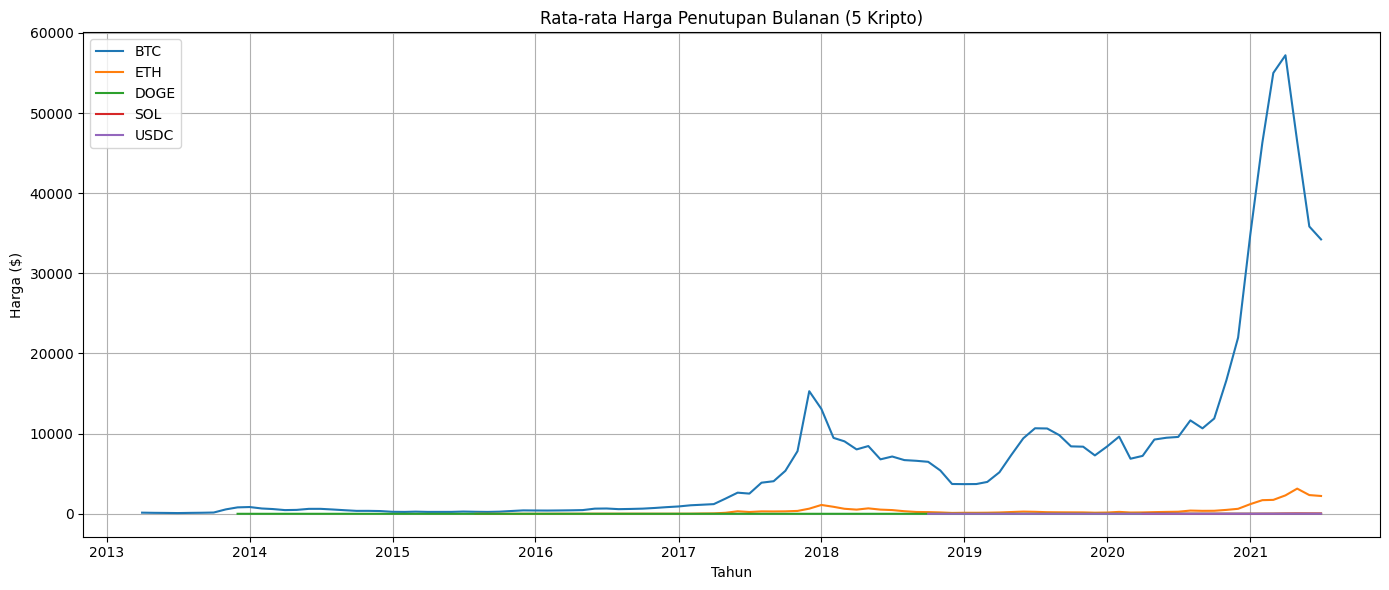

In [34]:
# Plot average monthly close price
plt.figure(figsize=(14, 6))
sns.lineplot(data=btc_pd, x="Date", y="Average Close Price", label="BTC")
sns.lineplot(data=eth_pd, x="Date", y="Average Close Price", label="ETH")
sns.lineplot(data=doge_pd, x="Date", y="Average Close Price", label="DOGE")
sns.lineplot(data=solana_pd, x="Date", y="Average Close Price", label="SOL")
sns.lineplot(data=usdc_pd, x="Date", y="Average Close Price", label="USDC")
plt.title("Rata-rata Harga Penutupan Bulanan (5 Kripto)")
plt.xlabel("Tahun")
plt.ylabel("Harga ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Berdasarkan diagram rata-rata harga bulanan kripto diatas, Bitcoin (BTC) memiliki kenaikan harga paling konsisten dibandingkan dengan kripto lainnya. Meskipun ada fluktuasi, BTC tetap menunjukkan kenaikan yang besar dengan penurunan yang lebih sedikit dan bisa dibilang lebih stabil dibandingkan dengan kripto yang lain sehingga Bitcoin (BTC) merupakan pilihan yang lebih aman dan lebih konsisten dalam hal harga dibandingkan dengan Ethereum, Dogecoin, Solana, dan USDC.

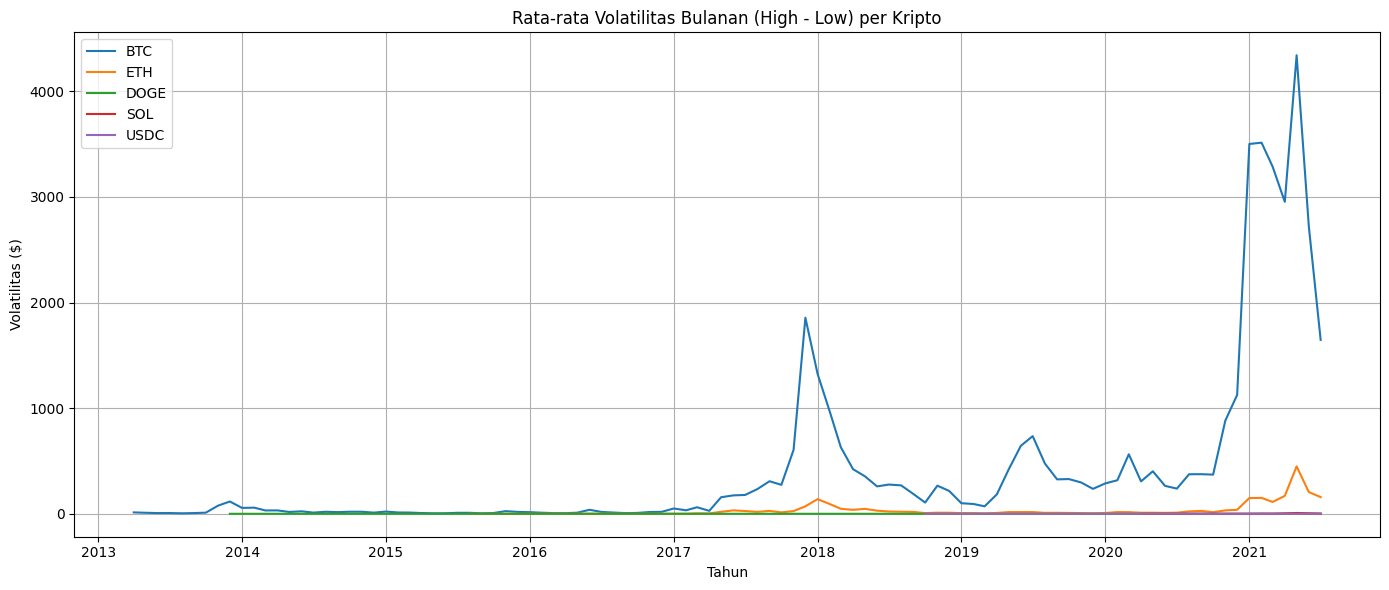

In [35]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=btc_vol_pd, x="Date", y="Avg Monthly Volatility", label="BTC")
sns.lineplot(data=eth_vol_pd, x="Date", y="Avg Monthly Volatility", label="ETH")
sns.lineplot(data=doge_vol_pd, x="Date", y="Avg Monthly Volatility", label="DOGE")
sns.lineplot(data=sol_vol_pd, x="Date", y="Avg Monthly Volatility", label="SOL")
sns.lineplot(data=usdc_vol_pd, x="Date", y="Avg Monthly Volatility", label="USDC")
plt.title("Rata-rata Volatilitas Bulanan (High - Low) per Kripto")
plt.xlabel("Tahun")
plt.ylabel("Volatilitas ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Berdasarkan grafik volatilitas kripto diatas, Bitcoin (BTC) juga menunjukkan volatilitas tertinggi secara keseluruhan. Pada analisis tersebut, volatilitasnya jauh lebih besar dibandingkan dengan kripto lain dengan angka lebih dari $4,000 pada beberapa titik di 2021. Ini menunjukkan bahwa meskipun Bitcoin memiliki tren harga yang stabil dan terus naik dalam jangka panjang, pergerakan harganya yang ekstrem (baik naik maupun turun) cukup sering terjadi. Di sisi lain, Ethereum (ETH) juga memiliki volatilitas yang besar meskipun tidak sebesar Bitcoin. Selain itu, Dogecoin (DOGE) dan Solana (SOL) menunjukkan volatilitas yang lebih rendah, tetapi ada lonjakan volatilitas pada tahun 2021. Terakhir, USD Coin (USDC) bisa dibilang stable coin karena tidak mengalami volatilitas sehingga nilainya tetap stabil yang selalu mendekati $1.